# Titanic Survival Prediction Using Machine Learning

## Project Overview

The Titanic disaster is one of the most well-known maritime tragedies in history. The objective of this project is to analyze passenger information and build a machine learning model capable of predicting whether a passenger survived the disaster.

Using demographic and travel-related information such as age, gender, ticket class, and fare, we aim to identify factors that influenced survival.

## Goals

- Explore passenger data
- Handle missing values
- Analyze survival patterns
- Build classification models
- Predict passenger survival

## Dataset Features

- Passenger Class (Pclass)
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked
- Survived (Target Variable)

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("Titanic-Dataset.csv")

# Dataset Exploration

Before training any machine learning model, it is important to understand the dataset structure.

This section examines:

- Dataset dimensions
- Data types
- Missing values
- Sample records

These checks help identify preprocessing requirements.

In [3]:
df.head()
# from here we can see important features that can contribute to the prediction would be [ 'Survived', 'Pclass',  'Sex', 'Age', 'SibSp',
       # 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Missing Value Analysis

Real-world datasets often contain incomplete information.

Missing values can affect model performance and therefore must be identified and handled appropriately before training.

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation

Several columns contain missing values, particularly Age and Embarked.

Appropriate imputation techniques will be applied to ensure data quality before model training.

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

# Data Cleaning and Preprocessing

Data cleaning ensures that the dataset is suitable for machine learning.

The following preprocessing steps are performed:

- Handling missing values
- Removing unnecessary columns
- Encoding categorical variables
- Converting features into machine-readable format

In [8]:
numerical_cols=df.select_dtypes(include=["float64","int64"]).columns
categorical_cols=df.select_dtypes(include=["object"]).columns

In [9]:
from sklearn.impute import SimpleImputer
mean=SimpleImputer(strategy="mean")
most_freq=SimpleImputer(strategy="most_frequent")

In [10]:
df[numerical_cols]=mean.fit_transform(df[numerical_cols])
df[categorical_cols]=most_freq.fit_transform(df[categorical_cols])

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

# EDA

# Survival Analysis by Gender

Gender was one of the most important factors influencing survival during the Titanic disaster.

This visualization compares survival outcomes across male and female passengers.

Text(0.5, 1.0, 'Survival distribution based on gender')

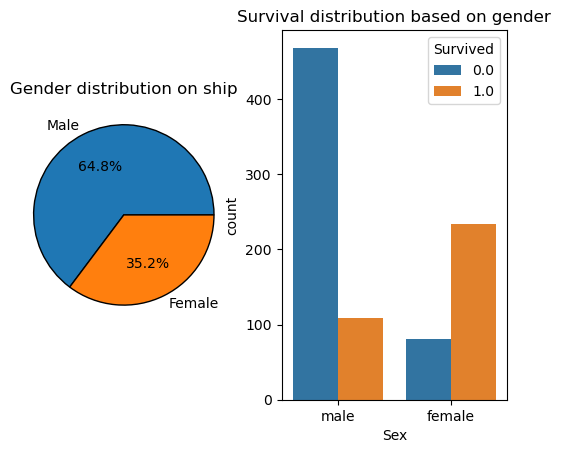

In [12]:
fig,ax=plt.subplots(1,2)
# 1)here we can see that gender distribution on the ship
gen_cnt=df["Sex"].value_counts()
ax[0].pie(gen_cnt,labels=["Male","Female"],autopct= "%1.1f%%",wedgeprops={"edgecolor":"black"})
ax[0].set_title("Gender distribution on ship")
# 2)here we can see that gender distribution on the ship for survived
sns.countplot(data=df, x="Sex", hue="Survived")
ax[1].set_title("Survival distribution based on gender")

### Interpretation

Female passengers exhibit a significantly higher survival rate than male passengers.

This suggests that gender is an important predictor of survival.

In [13]:
plt.savefig("abc.png")

<Figure size 640x480 with 0 Axes>

In [14]:
#now we want to see distribution between survived male vs female ()and another based on age(histo)

<Axes: xlabel='Survived', ylabel='Parch'>

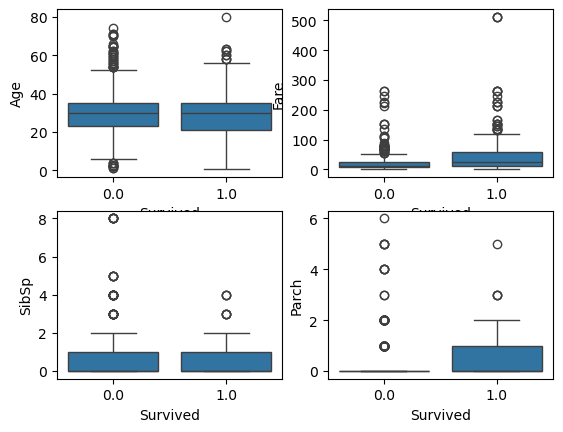

In [15]:
#we check otliers for age,fare,sibsp(siblings/ spouse),parch(parents/childrens)
fig,ax=plt.subplots(2,2)
sns.boxplot(ax=ax[0,0], data=df,y="Age",x="Survived")
sns.boxplot(ax=ax[0,1], data=df,y="Fare",x="Survived")
sns.boxplot(ax=ax[1,0], data=df,y="SibSp",x="Survived")
sns.boxplot(ax=ax[1,1], data=df,y="Parch",x="Survived")

# Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
Le=LabelEncoder()
cols=["Embarked","Sex"]
encoded=ohe.fit_transform(df[cols])
new_cols=ohe.get_feature_names_out(cols)
encoded_df=pd.DataFrame(encoded,columns=new_cols,index=df.index)



In [17]:
data=pd.concat([df,encoded_df],axis=1)
data=data.drop(columns=cols)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    float64
 1   Survived     891 non-null    float64
 2   Pclass       891 non-null    float64
 3   Name         891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    float64
 6   Parch        891 non-null    float64
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        891 non-null    object 
 10  Embarked_Q   891 non-null    float64
 11  Embarked_S   891 non-null    float64
 12  Sex_male     891 non-null    float64
dtypes: float64(10), object(3)
memory usage: 90.6+ KB


# correlation heatmap

In [18]:
num_cols=data.select_dtypes(include="float64")

In [19]:
corr_matrix=num_cols.corr()
print(corr_matrix)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.033207 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.069809 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.331339  0.083081  0.018443   
Age             0.033207 -0.069809 -0.331339  1.000000 -0.232625 -0.179191   
SibSp          -0.057527 -0.035322  0.083081 -0.232625  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.179191  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.091566  0.159651  0.216225   
Embarked_Q     -0.033606  0.003650  0.221009 -0.013855 -0.026354 -0.081228   
Embarked_S      0.022204 -0.149683  0.074053 -0.019336  0.068734  0.060814   
Sex_male        0.042939 -0.543351  0.131900  0.084153 -0.114631 -0.245489   

                 Fare  Embarked_Q  Embarked_S  Sex_male  
PassengerId  0.012658   -0.033606    0.022204  0.042939  
Survived     0.257307    

# Correlation Analysis

Correlation analysis measures relationships between numerical variables.

The heatmap provides insight into which features may be associated with survival.

<Axes: >

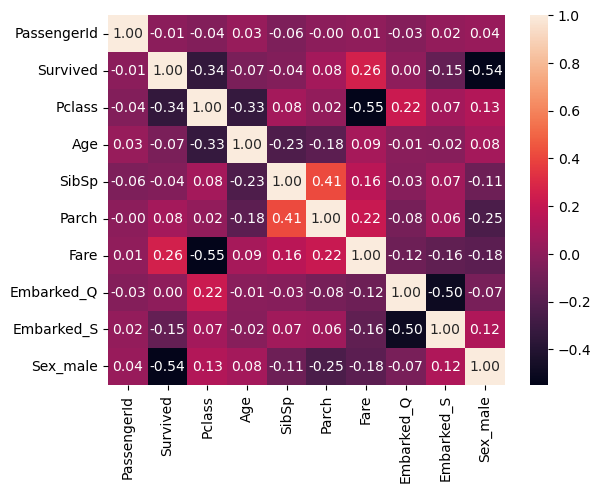

In [20]:
sns.heatmap(corr_matrix,annot=True,fmt=".2f")

### Interpretation

Features exhibiting stronger correlation with the target variable may contribute more significantly to survival prediction.

However, survival is influenced by multiple factors rather than a single feature.

In [21]:
data.columns
data=data.drop(columns=["PassengerId","Name","Cabin","Ticket"])

# model training and testing

In [22]:
x=data.drop(columns=["Survived"])
y=data["Survived"]

# Data Preparation

The dataset is divided into training and testing sets.

Training Set:
- Used for model learning

Testing Set:
- Used for performance evaluation on unseen data

This approach ensures an unbiased assessment of model performance.

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

# Model 1: Logistic Regression

Logistic Regression is a widely used classification algorithm for binary prediction problems.

Advantages:

- Simple and interpretable
- Fast training
- Effective baseline model

In [24]:
from sklearn.linear_model import LogisticRegression
model_1=LogisticRegression(max_iter=1000)
model_1.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred_1=model_1.predict(x_test)


In [26]:
from sklearn.metrics import confusion_matrix , classification_report
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_1)) 
print("\n")

print("classification report\n",classification_report(y_test,y_pred_1))


Confusion Matrix 
 [[90 15]
 [19 55]]


classification report
               precision    recall  f1-score   support

         0.0       0.83      0.86      0.84       105
         1.0       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [27]:
#lasso 
model_2=LogisticRegression(l1_ratio=1,C=.5,max_iter=1000,random_state=42,solver="liblinear")
model_2.fit(x_train,y_train)
y_pred_2=model_2.predict(x_test)
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_2)) 
print("\n")

print("classification report\n",classification_report(y_test,y_pred_2))


Confusion Matrix 
 [[90 15]
 [23 51]]


classification report
               precision    recall  f1-score   support

         0.0       0.80      0.86      0.83       105
         1.0       0.77      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [28]:
# ridge
model_3=LogisticRegression(l1_ratio=0,C=.5,max_iter=1000,random_state=42,solver="liblinear")
model_3.fit(x_train,y_train)
y_pred_3=model_3.predict(x_test)
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_3)) 
print("\n")

print("classification report\n",classification_report(y_test,y_pred_3))


Confusion Matrix 
 [[90 15]
 [23 51]]


classification report
               precision    recall  f1-score   support

         0.0       0.80      0.86      0.83       105
         1.0       0.77      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [29]:
#elasticnet
model_4=LogisticRegression(l1_ratio=.5,C=.5,max_iter=1000,random_state=42,solver="liblinear")
model_4.fit(x_train,y_train)
y_pred_4=model_4.predict(x_test)
print("Confusion Matrix \n",confusion_matrix(y_test,y_pred_4)) 
print("\n")

print("classification report\n",classification_report(y_test,y_pred_4))


Confusion Matrix 
 [[90 15]
 [23 51]]


classification report
               precision    recall  f1-score   support

         0.0       0.80      0.86      0.83       105
         1.0       0.77      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



C:\Users\akhil\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [30]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train,y_train)
y_p1=dtc.predict(x_test)
print("Confusion Matrix \n",confusion_matrix(y_test,y_p1)) 
print("\n")

print("classification report\n",classification_report(y_test,y_p1))


Confusion Matrix 
 [[89 16]
 [20 54]]


classification report
               precision    recall  f1-score   support

         0.0       0.82      0.85      0.83       105
         1.0       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [31]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(max_depth=6,min_samples_leaf=8)
dtc.fit(x_train,y_train)
y_p1=dtc.predict(x_test)
print("Confusion Matrix \n",confusion_matrix(y_test,y_p1)) 
print("\n")

print("classification report\n",classification_report(y_test,y_p1))


Confusion Matrix 
 [[97  8]
 [23 51]]


classification report
               precision    recall  f1-score   support

         0.0       0.81      0.92      0.86       105
         1.0       0.86      0.69      0.77        74

    accuracy                           0.83       179
   macro avg       0.84      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



# Model 2: Random Forest Classifier

Random Forest combines multiple decision trees to improve predictive performance.

Advantages:

- Handles non-linear relationships
- Captures complex feature interactions
- Robust against overfitting

In [32]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=101,random_state=42)
rf.fit(x_train,y_train)
y_p2=rf.predict(x_test)
print("classification report\n",classification_report(y_test,y_p2))

classification report
               precision    recall  f1-score   support

         0.0       0.83      0.87      0.85       105
         1.0       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [ ]:
# Conclusion

This project successfully applied machine learning techniques to predict passenger survival on the Titanic.

Key Findings:

- Gender strongly influenced survival outcomes.
- Passenger class significantly affected survival probability.
- Age also contributed to survival patterns.
- Machine learning models successfully captured these relationships.

Models Evaluated:

- Logistic Regression
- Random Forest Classifier

Future Improvements:

- Hyperparameter Tuning
- Cross Validation
- Feature Engineering
- XGBoost Classifier
- Ensemble Methods

This project demonstrates a complete machine learning classification workflow including data preprocessing, exploratory analysis, model training, and performance evaluation.